# 2장 2강: 퍼널 분석 — 전환율·이탈률 측정 원리 — 실습문제

## 실습 목표

- Ravenstack의 구독 여정을 순차적인 퍼널 단계로 정의할 수 있다.
- 이벤트 횟수와 고유 구독 수의 차이를 설명할 수 있다.
- 단계별 전환율과 이탈률을 계산할 수 있다.
- 막대형 퍼널을 시각화하고 이탈이 집중된 구간을 찾을 수 있다.
- 세그먼트별 퍼널을 비교하고 개선 가설을 제안할 수 있다.

## 실습 환경 / 데이터

- Python
- pandas
- matplotlib
- `ravenstack_subscriptions.csv`
- `ravenstack_feature_usage.csv`

이번 실습에서는 Ravenstack의 구독 여정을 다음과 같이 단순화합니다.

| 순서 | 퍼널 단계 | 집계 기준 |
|---:|---|---|
| 1 | 구독 시작 | `subscriptions`에 존재하는 고유 구독 |
| 2 | 기능 사용 | 기능 사용 기록이 한 번 이상 있는 구독 |
| 3 | 유료 구독 | 기능 사용 구독 중 `is_trial == False`인 구독 |
| 4 | 현재 유료 유지 | 이전 단계 구독 중 `end_date`가 비어 있는 구독 |

> 이 퍼널은 전환율 계산 원리를 익히기 위한 학습용 정의입니다. `is_trial`은 실제 유료 전환 시각을 기록한 이벤트가 아니므로 실제 전환 소요 시간이나 행동 순서를 완전히 재구성할 수는 없습니다.

In [1]:
import pandas as pd

# 가로 너비 제한 해제 (열 줄바꿈 방지)
pd.set_option("display.width", 1000)

# 생략(..) 없이 모든 열 출력
pd.set_option("display.max_columns", None)

# 표시할 최대 행 수 조정 (필요 시)
pd.set_option("display.max_rows", 50)

## 실습 준비

1. 필요한 라이브러리를 불러오세요.
2. 두 CSV 파일을 각각 `subscriptions`, `feature_usage`에 불러오세요.
3. 각 데이터의 행과 열 개수, 상위 5개 행을 확인하세요.
4. 분석 대상 컬럼의 자료형과 결측치 개수를 확인하세요.
5. `start_date`, `end_date`, `usage_date`를 날짜형으로 변환하세요.
6. 구독 ID의 고유 개수와 기능 사용 이벤트 행 수를 확인하세요.
7. `usage_id`의 중복 개수를 확인하고, 중복 ID를 바로 삭제하면 안 되는 이유를 생각해보세요.

In [2]:
# 실습 준비 코드를 작성하세요.
import numpy as np
import pandas as pd

subscriptions = pd.read_csv("ravenstack_subscriptions.csv")
feature_usage = pd.read_csv("ravenstack_feature_usage.csv")

print("=== Subscriptions Shape ===")
print(subscriptions.shape)
print("\n=== Subscriptions Head ===")
print(subscriptions.head())

print("\n=== Feature Usage Shape ===")
print(feature_usage.shape)
print("\n=== Feature Usage Head ===")
print(feature_usage.head())

print("\n=== Subscriptions Info & Missing Values ===")
print(subscriptions.info())
print("\n[결측치 개수]")
print(subscriptions.isnull().sum())

print("\n=== Feature Usage Info & Missing Values ===")
print(feature_usage.info())
print("\n[결측치 개수]")
print(feature_usage.isnull().sum())

subscriptions["start_date"] = pd.to_datetime(subscriptions["start_date"])
subscriptions["end_date"] = pd.to_datetime(subscriptions["end_date"])

feature_usage["usage_date"] = pd.to_datetime(feature_usage["usage_date"])

print("\n변환 후 컬럼 자료형 확인:")
print(
    f"subscriptions['start_date']: {subscriptions['start_date'].dtype}, ['end_date']: {subscriptions['end_date'].dtype}"
)
print(f"feature_usage['usage_date']: {feature_usage['usage_date'].dtype}")

n_unique_sub_in_subs = subscriptions["subscription_id"].nunique()
n_unique_sub_in_usage = feature_usage["subscription_id"].nunique()
n_usage_events = len(feature_usage)

print(
    f"\nsubscriptions 테이블의 고유 subscription_id 개수: {n_unique_sub_in_subs:,}개"
)
print(
    f"feature_usage 테이블의 고유 subscription_id 개수: {n_unique_sub_in_usage:,}개"
)
print(f"총 기능 사용(feature_usage) 이벤트 행 수: {n_usage_events:,}건")

duplicate_usage_ids = feature_usage["usage_id"].duplicated().sum()
print(f"\nusage_id 중복 개수: {duplicate_usage_ids:,}개")

=== Subscriptions Shape ===
(5000, 14)

=== Subscriptions Head ===
  subscription_id account_id  start_date    end_date   plan_tier  seats  mrr_amount  arr_amount  is_trial  upgrade_flag  downgrade_flag  churn_flag billing_frequency  auto_renew_flag
0        S-8cec59   A-3c1a3f  2023-12-23  2024-04-12  Enterprise     14        2786       33432     False         False           False        True           monthly             True
1        S-0f6f44   A-9b9fe9  2024-06-11         NaN         Pro     17         833        9996     False         False           False       False           monthly             True
2        S-51c0d1   A-659280  2024-11-25         NaN  Enterprise     62           0           0      True          True           False       False            annual            False
3        S-f81687   A-e7a1e2  2024-11-23  2024-12-13  Enterprise      5         995       11940     False         False           False        True           monthly             True
4        S-cff5a2 

---

## 필수 1. 전체 구독 퍼널의 전환율과 이탈률 계산하기

### 문제 1-1. Ravenstack 구독은 어느 구간에서 가장 많이 이탈하는가?

#### 문제 설명

전체 Ravenstack 구독을 대상으로 네 단계의 고유 구독 수를 계산하고, 각 구간의 전환율과 이탈률을 구하세요.

각 단계는 반드시 앞 단계를 통과한 구독만 포함해야 합니다. 예를 들어 유료 구독 단계는 전체 유료 구독이 아니라 **기능 사용 단계에 포함되면서 유료인 구독**으로 계산합니다.

#### 요구사항

1. 전체 구독 ID를 `started_ids`로 만드세요.
2. 기능 사용 기록이 있는 구독 ID와 `started_ids`의 교집합을 `used_ids`로 만드세요.
3. `used_ids`와 체험이 아닌 구독 ID의 교집합을 `paid_ids`로 만드세요.
4. `paid_ids`와 종료일이 비어 있는 구독 ID의 교집합을 `retained_paid_ids`로 만드세요.
5. 단계명과 고유 구독 수를 사용하여 `funnel` 데이터프레임을 만드세요.
6. 다음 식으로 구간 전환율과 이탈률을 계산하세요.
   - 전환율 = 현재 단계 구독 수 ÷ 이전 단계 구독 수
   - 이탈률 = 1 - 전환율
7. 각 구간의 이탈 구독 수도 계산하세요.
8. 단계별 구독 수를 막대그래프로 시각화하세요.
9. 전환율이 가장 낮은 구간을 찾고 개선 가설을 한 가지 제안하세요.

#### 해석 질문

**Q1.** 기능 사용 이벤트 행 수 대신 고유 구독 수를 사용해야 하는 이유는 무엇인가요?  
**Q2.** 전환율이 가장 낮고 이탈 구독 수가 가장 많은 구간은 어디인가요?  
**Q3.** 전환율과 이탈률을 더하면 얼마인가요?  
**Q4.** 낮은 전환율만으로 실제 이탈 원인을 확정할 수 있나요?

#### 제출 결과

- 단계별 고유 구독 집합
- `funnel` 데이터프레임
- 전환율·이탈률·이탈 구독 수
- 막대형 퍼널
- 이탈 집중 구간과 개선 가설
- Q1~Q4 답변

1단계 (전체 구독): 5,000개
2단계 (기능 사용): 4,967개
3단계 (유료 전환): 4,193개
4단계 (유료 유지): 3,788개

=== 퍼널 분석 결과 (funnel DataFrame) ===


,step,subscriptions,dropped_users,conversion_rate,churn_rate
0,1. Started,5000,0,1.000000,0.000000
1,2. Feature Used,4967,33,0.993400,0.006600
2,3. Paid Converted,4193,774,0.844172,0.155828
3,4. Paid Retained,3788,405,0.903410,0.096590


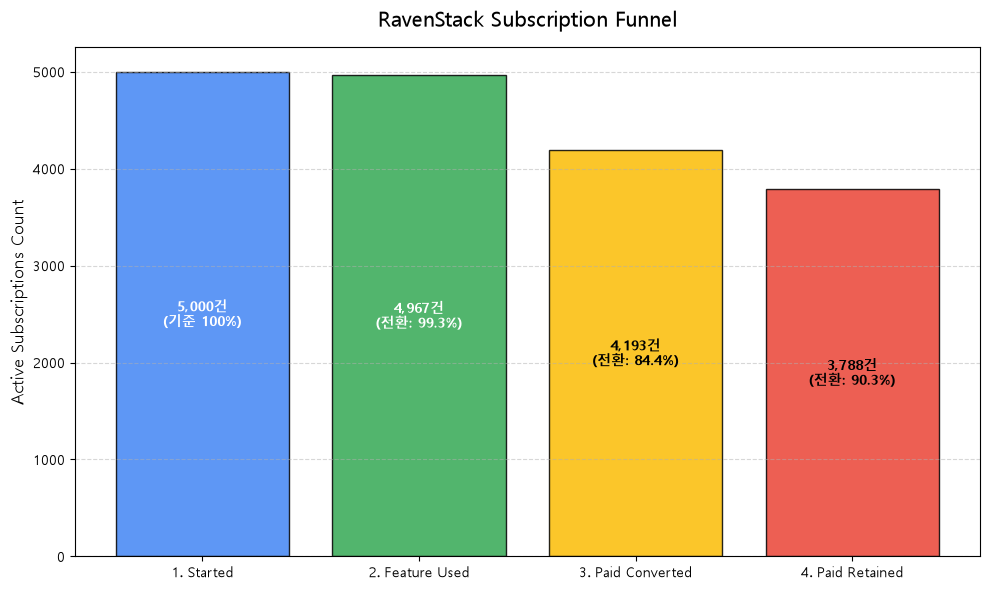

In [3]:
# 필수 1 코드를 작성하세요.
import matplotlib.pyplot as plt
import pandas as pd

import matplotlib.pyplot as plt
plt.rcParams['font.family'] ='Malgun Gothic'
plt.rcParams['axes.unicode_minus'] =False

# ----------------------------------------------------
# 1~4. 단계별 고유 구독 ID 집합 생성 (앞 단계 통과 기준)
# ----------------------------------------------------
# 1. 전체 구독 ID 집합
started_ids = set(subscriptions["subscription_id"])

# 2. 기능 사용 기록이 있는 구독 ID 집합 (started_ids 교집합)
used_ids = set(feature_usage["subscription_id"]).intersection(started_ids)

# 3. 기능 사용 구독 중 유료 구독 ID 집합 (is_trial == False)
paid_condition_ids = set(
    subscriptions[subscriptions["is_trial"] == False]["subscription_id"]
)
paid_ids = used_ids.intersection(paid_condition_ids)

# 4. 유료 구독 중 종료일(end_date)이 비어 있는(유지된) 구독 ID 집합
active_condition_ids = set(
    subscriptions[subscriptions["end_date"].isna()]["subscription_id"]
)
retained_paid_ids = paid_ids.intersection(active_condition_ids)

# 각 단계 고유 구독 수 확인
print(f"1단계 (전체 구독): {len(started_ids):,}개")
print(f"2단계 (기능 사용): {len(used_ids):,}개")
print(f"3단계 (유료 전환): {len(paid_ids):,}개")
print(f"4단계 (유료 유지): {len(retained_paid_ids):,}개")

# ----------------------------------------------------
# 5~7. funnel 데이터프레임 생성 및 전환율/이탈률/이탈 구독 수 계산
# ----------------------------------------------------
funnel = pd.DataFrame(
    {
        "step": [
            "1. Started",
            "2. Feature Used",
            "3. Paid Converted",
            "4. Paid Retained",
        ],
        "subscriptions": [
            len(started_ids),
            len(used_ids),
            len(paid_ids),
            len(retained_paid_ids),
        ],
    }
)

# 이전 단계 구독 수
funnel["prev_subscriptions"] = funnel["subscriptions"].shift(1)

# 전환율: 현재 단계 구독 수 ÷ 이전 단계 구독 수 (첫 단계는 1.0)
funnel["conversion_rate"] = (
    funnel["subscriptions"] / funnel["prev_subscriptions"]
).fillna(1.0)

# 이탈률: 1 - 전환율 (첫 단계는 0.0)
funnel["churn_rate"] = 1.0 - funnel["conversion_rate"]

# 이탈 구독 수: 이전 단계 구독 수 - 현재 단계 구독 수 (첫 단계는 0)
funnel["dropped_users"] = (
    (funnel["prev_subscriptions"] - funnel["subscriptions"])
    .fillna(0)
    .astype(int)
)

# 결과 출력
print("\n=== 퍼널 분석 결과 (funnel DataFrame) ===")
display(
    funnel[
        [
            "step",
            "subscriptions",
            "dropped_users",
            "conversion_rate",
            "churn_rate",
        ]
    ]
)

# ----------------------------------------------------
# 8. 단계별 구독 수 막대그래프 시각화
# ----------------------------------------------------
plt.figure(figsize=(10, 6))
bars = plt.bar(
    funnel["step"],
    funnel["subscriptions"],
    color=["#4285F4", "#34A853", "#FBBC05", "#EA4335"],
    edgecolor="black",
    alpha=0.85,
)

# 막대 상단에 수치 및 전환율 레이블 표기
for i, bar in enumerate(bars):
    height = bar.get_height()
    conv = funnel.loc[i, "conversion_rate"]
    text = (
        f"{height:,}건\n(전환: {conv:.1%})"
        if i > 0
        else f"{height:,}건\n(기준 100%)"
    )
    plt.text(
        bar.get_x() + bar.get_width() / 2.0,
        height / 2,
        text,
        ha="center",
        va="center",
        color="white" if i in [0, 1] else "black",
        fontweight="bold",
    )

plt.title("RavenStack Subscription Funnel", fontsize=15, pad=15)
plt.ylabel("Active Subscriptions Count", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

### 필수 1 답변 작성란

**Q1.** 기능 사용 이벤트 행 수 대신 고유 구독 수를 사용해야 하는 이유는 무엇인가요?  
- 같은 구독에서 기능 사용 이벤트가 여러번 발생할 수 있어서 중복 계산될 위험성이 있다.

**Q2.** 전환율이 가장 낮고 이탈 구독 수가 가장 많은 구간은 어디인가요?
- 기능사용->유료구독 전환 구간. 전환율 84.4%, 이탈 구독 774명

**Q3.** 전환율과 이탈률을 더하면 얼마인가요?  
- 100%

**Q4.** 낮은 전환율만으로 실제 이탈 원인을 확정할 수 있나요?
- 아니오. 

---

## 필수 2. 요금제별 퍼널 비교하기

### 문제 2-1. 요금제에 따라 이탈 구간이 다른가?

#### 문제 설명

`Basic`, `Pro`, `Enterprise` 요금제별로 동일한 퍼널을 계산하고 구간 전환율을 비교하세요. 그룹별 비교를 통해 특정 요금제에 문제가 집중되어 있는지 확인합니다.

#### 요구사항

1. 요금제별 퍼널을 계산하는 함수 `calculate_segment_funnel()`을 작성하세요.
2. 함수는 필수 1과 동일한 네 단계의 고유 구독 수와 구간 전환율을 반환해야 합니다.
3. 세 요금제의 결과를 결합하여 `plan_funnel`을 만드세요.
4. 첫 단계를 제외한 구간별 전환율을 요금제별 막대그래프로 시각화하세요.
5. 모든 요금제와 구간의 조합 중 전환율이 가장 낮은 조합을 찾으세요.
6. 해당 요금제와 구간을 우선 점검 대상으로 정하고 개선 가설을 한 가지 제안하세요.
7. 요금제별 차이가 크지 않을 경우 해석에서 그 사실도 언급하세요.

#### 해석 질문

**Q1.** 전환율이 가장 낮은 요금제와 구간의 조합은 무엇인가요?  
**Q2.** 요금제별 퍼널 비교가 전체 퍼널만 보는 것보다 유용한 이유는 무엇인가요?  
**Q3.** 관찰된 요금제별 차이는 큰 편인가요?  
**Q4.** 개선 가설을 확인하기 위해 어떤 데이터를 추가로 살펴볼 수 있나요?

#### 제출 결과

- 요금제별 퍼널 계산 함수
- `plan_funnel` 결과
- 요금제별 전환율 그래프
- 우선 점검 대상과 개선 가설
- Q1~Q4 답변

=== 요금제별 퍼널 요약 (plan_funnel) ===


,plan_tier,step,subscriptions,dropped_users,conversion_rate,churn_rate
0,Basic,1. Started,1602,0,1.000000,0.000000
1,Basic,2. Feature Used,1588,14,0.991261,0.008739
2,Basic,3. Paid Converted,1343,245,0.845718,0.154282
3,Basic,4. Paid Retained,1217,126,0.906180,0.093820
4,Pro,1. Started,1675,0,1.000000,0.000000
5,Pro,2. Feature Used,1665,10,0.994030,0.005970
6,Pro,3. Paid Converted,1407,258,0.845045,0.154955
7,Pro,4. Paid Retained,1273,134,0.904762,0.095238
8,Enterprise,1. Started,1723,0,1.000000,0.000000
9,Enterprise,2. Feature Used,1714,9,0.994777,0.005223


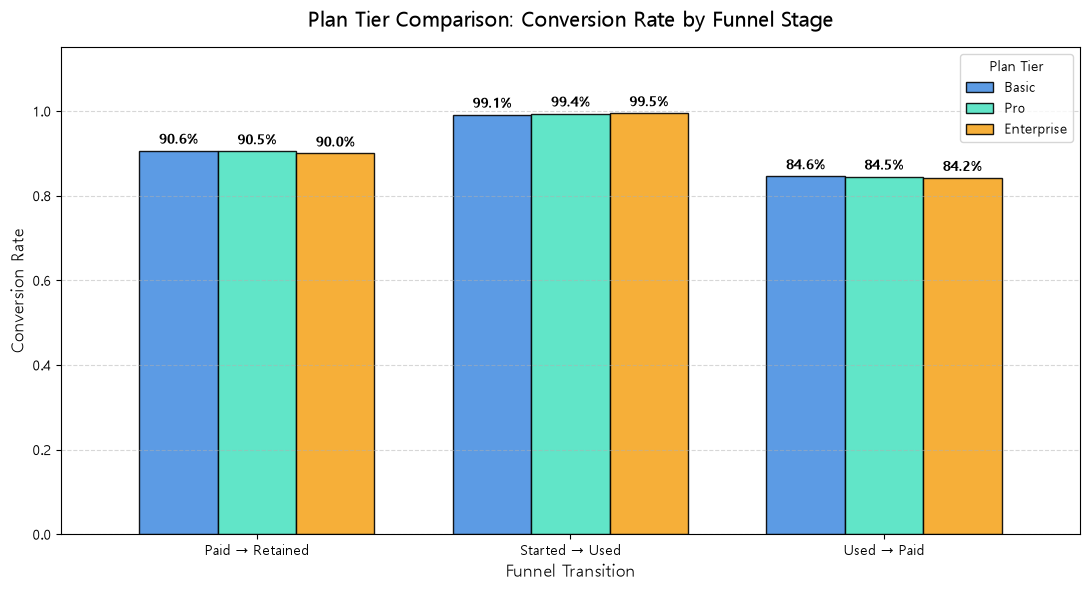


[최저 전환율 구간] 요금제: Enterprise | 구간: Used → Paid | 전환율: 84.19%


In [5]:
# 필수 2 코드를 작성하세요.
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


# ----------------------------------------------------
# 1~2. 요금제별 퍼널 계산 함수 정의
# ----------------------------------------------------
def calculate_segment_funnel(
    sub_df: pd.DataFrame, usage_df: pd.DataFrame, plan_name: str
) -> pd.DataFrame:
    """특정 요금제(plan_tier)를 대상으로 필수 1과 동일한 4단계 고유 구독 수와

    구간 전환율(conversion_rate)을 계산합니다.
    """
    # 해당 요금제에 속하는 전체 구독 데이터 필터링
    plan_subs = sub_df[sub_df["plan_tier"] == plan_name]

    # 1단계: 전체 구독 ID 집합
    started_ids = set(plan_subs["subscription_id"])

    # 2단계: 기능 사용 기록이 있는 구독 ID 집합 (started_ids 교집합)
    used_ids = set(usage_df["subscription_id"]).intersection(started_ids)

    # 3단계: 기능 사용 구독 중 유료 구독 ID 집합 (is_trial == False)
    paid_condition_ids = set(
        plan_subs[plan_subs["is_trial"] == False]["subscription_id"]
    )
    paid_ids = used_ids.intersection(paid_condition_ids)

    # 4단계: 유료 구독 중 종료일(end_date)이 비어 있는(유지된) 구독 ID 집합
    active_condition_ids = set(
        plan_subs[plan_subs["end_date"].isna()]["subscription_id"]
    )
    retained_paid_ids = paid_ids.intersection(active_condition_ids)

    # 데이터프레임 구성
    steps = [
        "1. Started",
        "2. Feature Used",
        "3. Paid Converted",
        "4. Paid Retained",
    ]
    counts = [
        len(started_ids),
        len(used_ids),
        len(paid_ids),
        len(retained_paid_ids),
    ]

    df_funnel = pd.DataFrame(
        {"plan_tier": plan_name, "step": steps, "subscriptions": counts}
    )

    # 이전 단계 구독 수 및 구간 전환율 계산
    df_funnel["prev_subscriptions"] = df_funnel["subscriptions"].shift(1)
    df_funnel["conversion_rate"] = (
        df_funnel["subscriptions"] / df_funnel["prev_subscriptions"]
    ).fillna(1.0)
    df_funnel["churn_rate"] = 1.0 - df_funnel["conversion_rate"]
    df_funnel["dropped_users"] = (
        (df_funnel["prev_subscriptions"] - df_funnel["subscriptions"])
        .fillna(0)
        .astype(int)
    )

    return df_funnel


# ----------------------------------------------------
# 3. Basic, Pro, Enterprise 요금제 결과 결합 (plan_funnel)
# ----------------------------------------------------
plans = ["Basic", "Pro", "Enterprise"]
plan_funnel_list = [
    calculate_segment_funnel(subscriptions, feature_usage, plan)
    for plan in plans
]
plan_funnel = pd.concat(plan_funnel_list, ignore_index=True)

print("=== 요금제별 퍼널 요약 (plan_funnel) ===")
display(
    plan_funnel[
        [
            "plan_tier",
            "step",
            "subscriptions",
            "dropped_users",
            "conversion_rate",
            "churn_rate",
        ]
    ]
)

# ----------------------------------------------------
# 4. 첫 단계를 제외한 구간별 전환율 요금제별 막대그래프 시각화
# ----------------------------------------------------
# 첫 단계(1. Started) 제외 필터링
transition_df = plan_funnel[plan_funnel["step"] != "1. Started"].copy()

# 단계명 단순화 (시각화 가독성)
step_mapping = {
    "2. Feature Used": "Started → Used",
    "3. Paid Converted": "Used → Paid",
    "4. Paid Retained": "Paid → Retained",
}
transition_df["transition"] = transition_df["step"].map(step_mapping)

# 피벗 테이블 생성: Index=구간, Columns=요금제, Values=전환율
pivot_conv = transition_df.pivot(
    index="transition", columns="plan_tier", values="conversion_rate"
)[plans]

# 시각화
ax = pivot_conv.plot(
    kind="bar",
    figsize=(11, 6),
    width=0.75,
    color=["#4A90E2", "#50E3C2", "#F5A623"],
    edgecolor="black",
    alpha=0.9,
)

plt.title("Plan Tier Comparison: Conversion Rate by Funnel Stage", fontsize=15, pad=15)
plt.xlabel("Funnel Transition", fontsize=12)
plt.ylabel("Conversion Rate", fontsize=12)
plt.ylim(0, 1.15)
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.5)

# 막대 상단에 수치(퍼센트) 표기
for p in ax.patches:
    h = p.get_height()
    if h > 0:
        ax.annotate(
            f"{h:.1%}",
            (p.get_x() + p.get_width() / 2.0, h),
            ha="center",
            va="bottom",
            fontsize=10,
            fontweight="bold",
            xytext=(0, 3),
            textcoords="offset points",
        )

plt.legend(title="Plan Tier", loc="upper right")
plt.tight_layout()
plt.show()

# ----------------------------------------------------
# 5. 모든 요금제와 구간의 조합 중 전환율이 가장 낮은 조합 찾기
# ----------------------------------------------------
min_row = transition_df.loc[transition_df["conversion_rate"].idxmin()]
print(
    f"\n[최저 전환율 구간] 요금제: {min_row['plan_tier']} | 구간: {min_row['transition']} | 전환율: {min_row['conversion_rate']:.2%}"
)

### 필수 2 답변 작성란

**Q1.** 전환율이 가장 낮은 요금제와 구간의 조합은 무엇인가요?
- 요금제: Enterprise / 구간: Used → Paid / 전환율 84.19%

**Q2.** 요금제별 퍼널 비교가 전체 퍼널만 보는 것보다 유용한 이유는 무엇인가요?  
- 어느 세그먼트에서 문제가 있는지 알 수 있다. 개선 대상을 더 구체적으로 정할 수 있다.

**Q3.** 관찰된 요금제별 차이는 큰 편인가요?  
- 아니오. 요금제간의 차이는 모든 구간에서 1% 내외이다.

**Q4.** 개선 가설을 확인하기 위해 어떤 데이터를 추가로 살펴볼 수 있나요?
- 체험 종료 데이터, churn_events.csv의 reason_code 및 feedback_text: 이탈한 고객들이 밝힌 주된 사유가 무엇인지 분석

---

## 과제 1. 평가 문항 기반 독립 과제

### 문제 3-1. 결제 주기별 퍼널 비교하기

#### 문제 설명

월간 결제 구독과 연간 결제 구독의 퍼널을 비교하여 상대적으로 전환율이 낮은 그룹과 구간을 찾으세요.

> 이 과제는 필수 2에서 만든 함수와 분석 절차를 `billing_frequency`에 동일하게 적용하는 문제입니다.

#### 요구사항

1. `calculate_segment_funnel()`을 사용하여 `monthly`, `annual`의 퍼널을 계산하세요.
2. 두 결과를 결합하여 `billing_funnel`을 만드세요.
3. 첫 단계를 제외한 구간 전환율을 결제 주기별 막대그래프로 시각화하세요.
4. 모든 결제 주기와 구간의 조합 중 전환율이 가장 낮은 조합을 찾으세요.
5. 해당 그룹과 구간에 대한 개선 가설을 한 가지 제안하세요.
6. 퍼널 결과만으로 원인을 확정할 수 없는 이유와 추가 확인할 데이터를 설명하세요.

#### 해석 질문

**Q1.** 전환율이 가장 낮은 결제 주기와 구간의 조합은 무엇인가요?  
**Q2.** 해당 구간의 전환율과 이탈률은 얼마인가요?  
**Q3.** 이 결과만으로 결제 주기가 이탈의 원인이라고 말할 수 있나요?

#### 제출 결과

- `billing_funnel` 결과
- 결제 주기별 전환율 그래프
- 우선 점검 대상과 개선 가설
- 분석의 한계와 추가 확인 데이터
- Q1~Q3 답변

In [ ]:
# 과제 1 코드를 작성하세요.
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


# ----------------------------------------------------
# 1. 세그먼트별 퍼널 계산 함수 (billing_frequency 대상 적용)
# ----------------------------------------------------
def calculate_segment_funnel(
    sub_df: pd.DataFrame,
    usage_df: pd.DataFrame,
    segment_col: str,
    segment_value: str,
) -> pd.DataFrame:
    """특정 세그먼트(예: billing_frequency의 'monthly', 'annual')를 대상으로

    4단계 고유 구독 수, 구간 전환율, 이탈률을 계산합니다.
    """
    # 해당 세그먼트에 속하는 구독 필터링
    seg_subs = sub_df[sub_df[segment_col] == segment_value]

    # 1단계: 전체 구독 ID 집합 (Started)
    started_ids = set(seg_subs["subscription_id"])

    # 2단계: 기능 사용 기록이 있는 구독 ID 집합 (Feature Used)
    used_ids = set(usage_df["subscription_id"]).intersection(started_ids)

    # 3단계: 기능 사용 구독 중 유료 구독 ID 집합 (Paid Converted, is_trial == False)
    paid_condition_ids = set(
        seg_subs[seg_subs["is_trial"] == False]["subscription_id"]
    )
    paid_ids = used_ids.intersection(paid_condition_ids)

    # 4단계: 유료 구독 중 유지된 구독 ID 집합 (Paid Retained, end_date 결측)
    active_condition_ids = set(
        seg_subs[seg_subs["end_date"].isna()]["subscription_id"]
    )
    retained_paid_ids = paid_ids.intersection(active_condition_ids)

    steps = [
        "1. Started",
        "2. Feature Used",
        "3. Paid Converted",
        "4. Paid Retained",
    ]
    counts = [
        len(started_ids),
        len(used_ids),
        len(paid_ids),
        len(retained_paid_ids),
    ]

    df_funnel = pd.DataFrame(
        {
            "billing_frequency": segment_value,
            "step": steps,
            "subscriptions": counts,
        }
    )

    # 구간 지표 계산
    df_funnel["prev_subscriptions"] = df_funnel["subscriptions"].shift(1)
    df_funnel["conversion_rate"] = (
        df_funnel["subscriptions"] / df_funnel["prev_subscriptions"]
    ).fillna(1.0)
    df_funnel["churn_rate"] = 1.0 - df_funnel["conversion_rate"]
    df_funnel["dropped_users"] = (
        (df_funnel["prev_subscriptions"] - df_funnel["subscriptions"])
        .fillna(0)
        .astype(int)
    )

    return df_funnel


# ----------------------------------------------------
# 2. monthly 및 annual 퍼널 계산 및 billing_funnel 생성
# ----------------------------------------------------
frequencies = ["monthly", "annual"]
billing_funnel_list = [
    calculate_segment_funnel(
        subscriptions, feature_usage, "billing_frequency", freq
    )
    for freq in frequencies
]
billing_funnel = pd.concat(billing_funnel_list, ignore_index=True)

print("=== 결제 주기별 퍼널 결과 (billing_funnel) ===")
display(
    billing_funnel[
        [
            "billing_frequency",
            "step",
            "subscriptions",
            "dropped_users",
            "conversion_rate",
            "churn_rate",
        ]
    ]
)

# ----------------------------------------------------
# 3. 첫 단계를 제외한 구간별 전환율 막대그래프 시각화
# ----------------------------------------------------
# 첫 단계 제외
transition_df = billing_funnel[billing_funnel["step"] != "1. Started"].copy()

step_mapping = {
    "2. Feature Used": "Started → Used",
    "3. Paid Converted": "Used → Paid",
    "4. Paid Retained": "Paid → Retained",
}
transition_df["transition"] = transition_df["step"].map(step_mapping)

# 피벗 테이블 구성: Index=구간, Columns=결제주기, Values=전환율
pivot_conv = transition_df.pivot(
    index="transition", columns="billing_frequency", values="conversion_rate"
)[frequencies]

# 시각화
ax = pivot_conv.plot(
    kind="bar",
    figsize=(10, 6),
    width=0.7,
    color=["#4285F4", "#34A853"],
    edgecolor="black",
    alpha=0.9,
)

plt.title(
    "Billing Frequency Funnel Comparison: Conversion Rate", fontsize=15, pad=15
)
plt.xlabel("Funnel Transition", fontsize=12)
plt.ylabel("Conversion Rate", fontsize=12)
plt.ylim(0, 1.15)
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.5)

for p in ax.patches:
    h = p.get_height()
    if h > 0:
        ax.annotate(
            f"{h:.1%}",
            (p.get_x() + p.get_width() / 2.0, h),
            ha="center",
            va="bottom",
            fontsize=10,
            fontweight="bold",
            xytext=(0, 3),
            textcoords="offset points",
        )

plt.legend(title="Billing Frequency", loc="upper right")
plt.tight_layout()
plt.show()

# ----------------------------------------------------
# 4. 모든 조합 중 전환율이 가장 낮은 조합 찾기
# ----------------------------------------------------
min_row = transition_df.loc[transition_df["conversion_rate"].idxmin()]
print(
    f"\n[최저 전환율 조합] 결제주기: {min_row['billing_frequency']} | 구간: {min_row['transition']} | 전환율: {min_row['conversion_rate']:.2%}"
)

### 과제 1 답변 작성란

**Q1.** 전환율이 가장 낮은 결제 주기와 구간의 조합은 무엇인가요?  
- 결제주기: monthly | 구간: Used → Paid

**Q2.** 해당 구간의 전환율과 이탈률은 얼마인가요?  
- 전환율: 84.13% | 이탈률 15.87%

**Q3.** 이 결과만으로 결제 주기가 이탈의 원인이라고 말할 수 있나요?
- 아니오. 결제 주기는 고객이 선택한 결제 조건(옵션)일 뿐, 이탈을 일으킨 직접적인 인과적 원인(Causality)이라고 단정할 수 없다.



## 실습 마무리

아래 질문에 답하세요.

1. 이번 실습의 퍼널 단계를 어떻게 정의했나요?
- 구독 여부 - 기능 사용 - 유료 구독 - 구독 유지(종료 DATE가 없는)

2. 단계별 사용자 수 대신 어떤 식별자의 고유 개수를 사용했나요?
- 구독자 id의 고유값 사용

3. 전환율과 이탈률은 어떻게 계산했나요?
- 현재 단계 구독 수를 이전 단계 구독 수로 나누어 전환율 계산, 1에서 전환율을 빼서 이탈률을 계산

4. 전체 퍼널에서 가장 큰 문제가 나타난 구간은 어디였나요?
- 기능 사용 -> 유료 구독 전환 구간에서 약 15.6%가 이탈했다.

5. 퍼널 분석 결과와 실제 원인을 왜 구분해야 하나요?
- 퍼널은 어느 구간에서 사용자가 줄었는지는 보여주지만 가격, 기능, 문의 등 어떤 요인이 원인인지는 알려주지 않는다.